CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [ ]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.4MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.78MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.73MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [ ]:
# TODO
# 모델, 손실함수 및 최적화 알고리즘 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = myCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 10, gamma = 0.5)

모델 학습 ✅

In [ ]:
# TODO
def train(model, device, train_loader, optimizer, epoch):
  model.train()
  for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if batch_idx % 100 == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(epoch, batch_idx * len(data), len(train_loader.dataset), 100. * batch_idx / len(train_loader), loss.item()))


모델 평가 ✅

In [ ]:
# TODO
def test(model, device, test_loader):
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      test_loss += F.nll_loss(output, target, reduction = 'sum').item()
      pred = output.argmax(dim = 1, keepdim = True)
      correct += pred.eq(target.view_as(pred)).sum().item()
  test_loss /= len(test_loader.dataset)
  test_losses.append(test_loss)
  test_accuracy = 100. * correct / len(test_loader.dataset)
  test_accuracies.append(test_accuracy)
  print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(test_loss, correct, len(test_loader.dataset), test_accuracy))
  return test_loss, test_accuracy

10회 반복 시행 ✅

In [ ]:
# TODO
model.to(device)
test_losses = []
train_losses = []
test_accuracies = []
epochs=10

for epoch in range(1, epochs+1):
  train(model, device, train_loader, optimizer, epoch)
  test_loss, test_accuracy = test(model, device, test_loader)
  scheduler.step()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.303396
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.141216
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.093974
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.061066
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.106133
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.170916
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.049695
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.047437
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.010369
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.024846
Test set: Average loss: 0.0594, Accuracy: 9824/10000 (98.24%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.135656
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.084374
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.016225
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.057659
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.019470
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.004782
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.007862
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.058139
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.032188

결과 시각화

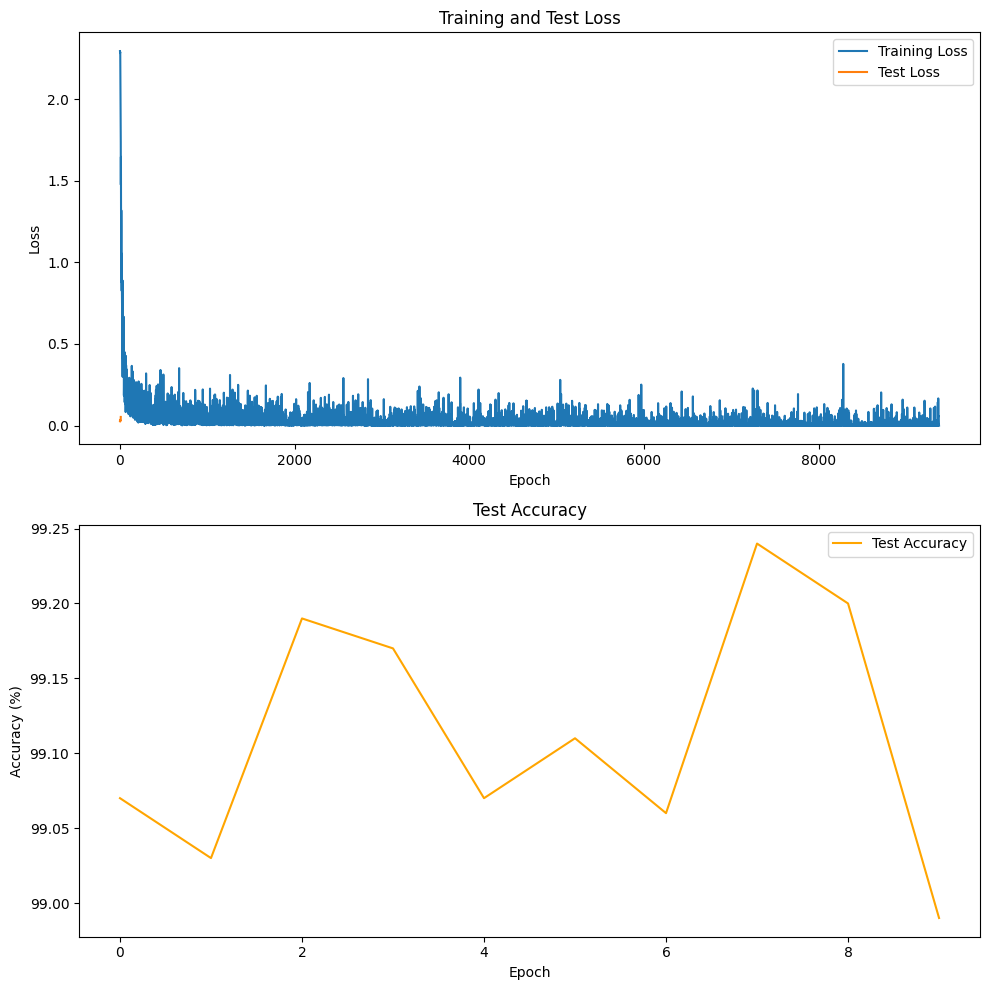

In [ ]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()

**대체로 98.후반대의 성능을 보이고 있으며, 10epoch까지 실행한 결과 그렇게 유의미한 성능차이가 발생하진 않는다. 더 epoch을 늘려도 더 좋은 성능 향상이 어려울 수 있으며, learning rate을 더 감소시키면 가능할 수도 있을 것같다. class가 불균형하다면, 불균형한 정도를 고려한 학습을 진행시킨다면 학습성능이 더 올라갈수도 있을 것인데, MNIST dataset는 그렇지 않기때문에 다른 optimizer를 사용하거나 오분류된 class 의 data 증강을 통해 성능을 향상시킬수있을 것이다.**